# Capstone 01 - Titanic Survival EDA

> **MLCourse · Data Science Foundations · 06_capstone_projects**

### Project brief
An insurer asks: *which passenger characteristics drove survival on the Titanic,
and how strong is each effect?* Deliver a defensible, quantified analysis with
one dashboard.

### Dataset
Seaborn's `titanic` (891 passengers). Column dictionary:

| column | meaning |
### |---|---|
### | survived | 0 = died, 1 = survived |
### | pclass / class | ticket class 1-3 |
### | sex, age | demographics (age has ~20% missing) |
### | sibsp, parch | siblings/spouses, parents/children aboard |
### | fare, embarked/embark_town | price & port (2 missing) |
### | deck | cabin deck (~77% missing!) |
### | who, adult_male, alone | derived convenience columns |


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    titanic_raw = sns.load_dataset("titanic")
except Exception as e:
    print("Offline? Load once online; seaborn caches afterwards.", e)
    raise

### Phase 1 - Audit


shape: (891, 15)

dtypes:
 str         5
int64       4
float64     2
bool        2
category    1
category    1
Name: count, dtype: int64

              n_missing  pct_missing  n_unique
age                177         19.9        88
embarked             2          0.2         3
deck               688         77.2         7
embark_town          2          0.2         3

duplicated full rows: 107


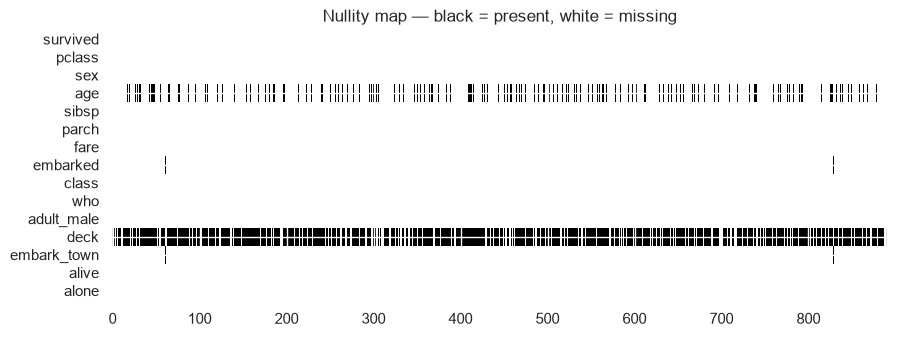

In [2]:
df = titanic_raw.copy()

print("shape:", df.shape)
print("\ndtypes:\n", df.dtypes.value_counts())

audit = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
})
print("\n", audit[audit.n_missing > 0])

print("\nduplicated full rows:", df.duplicated().sum())

# Nullity map (missingno-style, manual):
plt.figure(figsize=(10, 3.5))
plt.imshow(df.isna().T, aspect="auto", cmap="Greys", interpolation="nearest")
plt.yticks(range(len(df.columns)), df.columns)
plt.title("Nullity map - black = present, white = missing")
plt.show()

**Audit verdict:** `deck` is structurally missing (deck plans lost / bodies never
recovered → NOT random); `age` ~20% MAR-ish; `embark_town` trivially fixable.
We will DROP deck, IMPUTE age group-wise, mode-fill embarked.

In [3]:
df = df.drop(columns="deck")

group_medians = df.groupby(["class", "sex"], observed=True)["age"].transform("median")
df["age"] = df["age"].fillna(group_medians)
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

assert df[["age", "embarked"]].isna().sum().sum() == 0
print("cleaning pass 1 done ✓")

cleaning pass 1 done ✓


### Phase 2 - Feature engineering


In [4]:
# family_size: parents/kids + siblings/spouses + self.
df["family_size"] = df["sibsp"] + df["parch"] + 1

# is_alone: solo travelers are a classic risk segment.
df["is_alone"] = (df["family_size"] == 1).astype(int)

# fare_per_person: fares look like GROUP tickets - normalize!
df["fare_per_person"] = df["fare"] / df["family_size"]

# age_group: life-stage bands beat raw years for interpretation.
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["child", "teen", "young_adult", "adult", "senior"],
)

# log fare tames right skew for later numeric work:
df["fare_log1p"] = np.log1p(df["fare_per_person"])

df[["family_size", "is_alone", "fare_per_person",
    "fare_log1p", "age_group"]].head(6)

,family_size,is_alone,fare_per_person,fare_log1p,age_group
0,2,0,3.62500,1.531476,young_adult
1,2,0,35.64165,3.601186,adult
2,1,1,7.92500,2.188856,young_adult
3,2,0,26.55000,3.316003,young_adult
4,1,1,8.05000,2.202765,young_adult
5,1,1,8.45830,2.246893,young_adult


### Quick skew sanity check that motivated the log:


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(df["fare_per_person"], bins=40, color="salmon")
axes[0].set_title(f"fare/person (skew={df['fare_per_person'].skew():.1f})")
axes[1].hist(df["fare_log1p"], bins=40, color="seagreen")
axes[1].set_title(f"log1p (skew={df['fare_log1p'].skew():.1f})")
plt.show()


### Phase 3 - Who survived? Segmentation


In [6]:
overall_rate = df["survived"].mean()
print(f"overall survival: {overall_rate:.1%}")

def rate_table(by):
    """Survival rate + n per segment, sorted."""
    out = (df.groupby(by, observed=True)["survived"]
             .agg(rate="mean", n="size").sort_values("rate"))
    return out

for col in ["sex", "class", "who", "age_group", "is_alone"]:
    print("\n--- by", col, "---")
    print(rate_table(col).round(3))

overall survival: 38.4%

--- by sex ---
         rate    n
sex               
male    0.189  577
female  0.742  314

--- by class ---
         rate    n
class             
Third   0.242  491
Second  0.473  184
First   0.630  216

--- by who ---
        rate    n
who              
man    0.164  537
child  0.590   83
woman  0.756  271

--- by age_group ---
              rate    n
age_group              
senior       0.227   22
young_adult  0.358  514
adult        0.384  216
teen         0.429   70
child        0.580   69

--- by is_alone ---
           rate    n
is_alone            
1         0.304  537
0         0.506  354


sex     female  male
class               
First     96.8  36.9
Second    92.1  15.7
Third     50.0  13.5


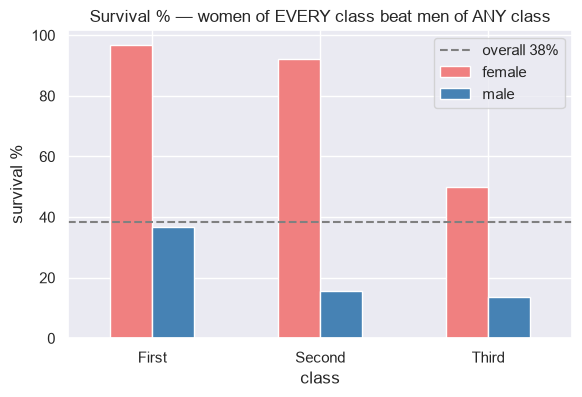

In [7]:
# The famous interaction: sex × class.
pivot = pd.pivot_table(df, index="class", columns="sex",
                       values="survived", aggfunc="mean")
print((pivot * 100).round(1))

fig, ax = plt.subplots(figsize=(6.5, 4))
(pivot * 100).plot(kind="bar", ax=ax,
                   color=["lightcoral", "steelblue"])
ax.axhline(overall_rate * 100, ls="--", color="gray",
           label=f"overall {overall_rate:.0%}")
ax.set_title("Survival % - women of EVERY class beat men of ANY class")
ax.set_ylabel("survival %"); ax.legend(); ax.set_xticklabels(ax.get_xticklabels(),
                                                             rotation=0)
plt.show()

> **Insight:** first-class women ≈ 97%, third-class men ≈ 15%. Class amplified
or dampened survival WITHIN each sex, but sex dominates every split.

### Children first? Compare kids vs adults within each class.


In [ ]:
kids = df.assign(is_child=df["age"] <= 12)          # children under 12
child_summary = (
    kids[kids["is_child"]]
        .groupby("class", observed=True)["survived"]
        .agg(child_survival="mean", n_children="size")
)
print(child_summary.round(3))
# > **Insight:** children enjoyed elevated survival in 2nd/3rd class but the tiny
#   1st-class sample (n=?) makes rates noisy - always report n beside rates.


### Phase 4 - Numeric structure & correlations


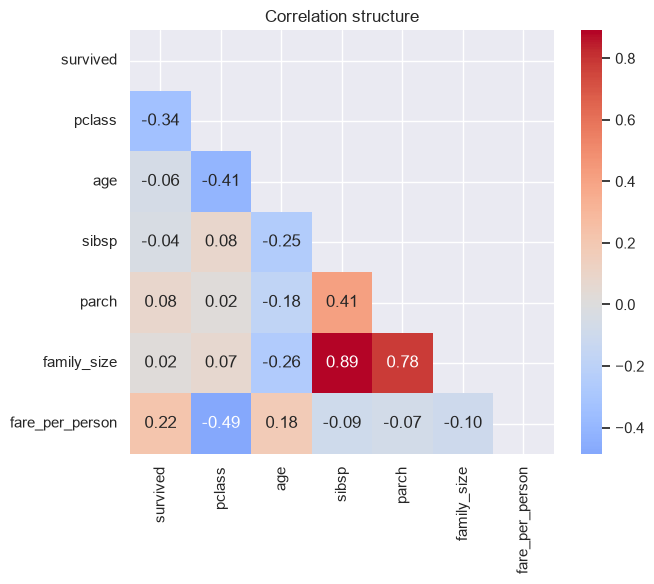

In [9]:
num_cols = ["survived", "pclass", "age", "sibsp", "parch",
            "family_size", "fare_per_person"]
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))       # hide upper triangle

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True)
plt.title("Correlation structure")
plt.show()

# > **Insight:** survived↔pclass -0.34 (higher class number = lower survival);
#   fare↔pclass strongly negative; family_size≈sibsp+parch by construction.

### Phase 5 - Dashboard


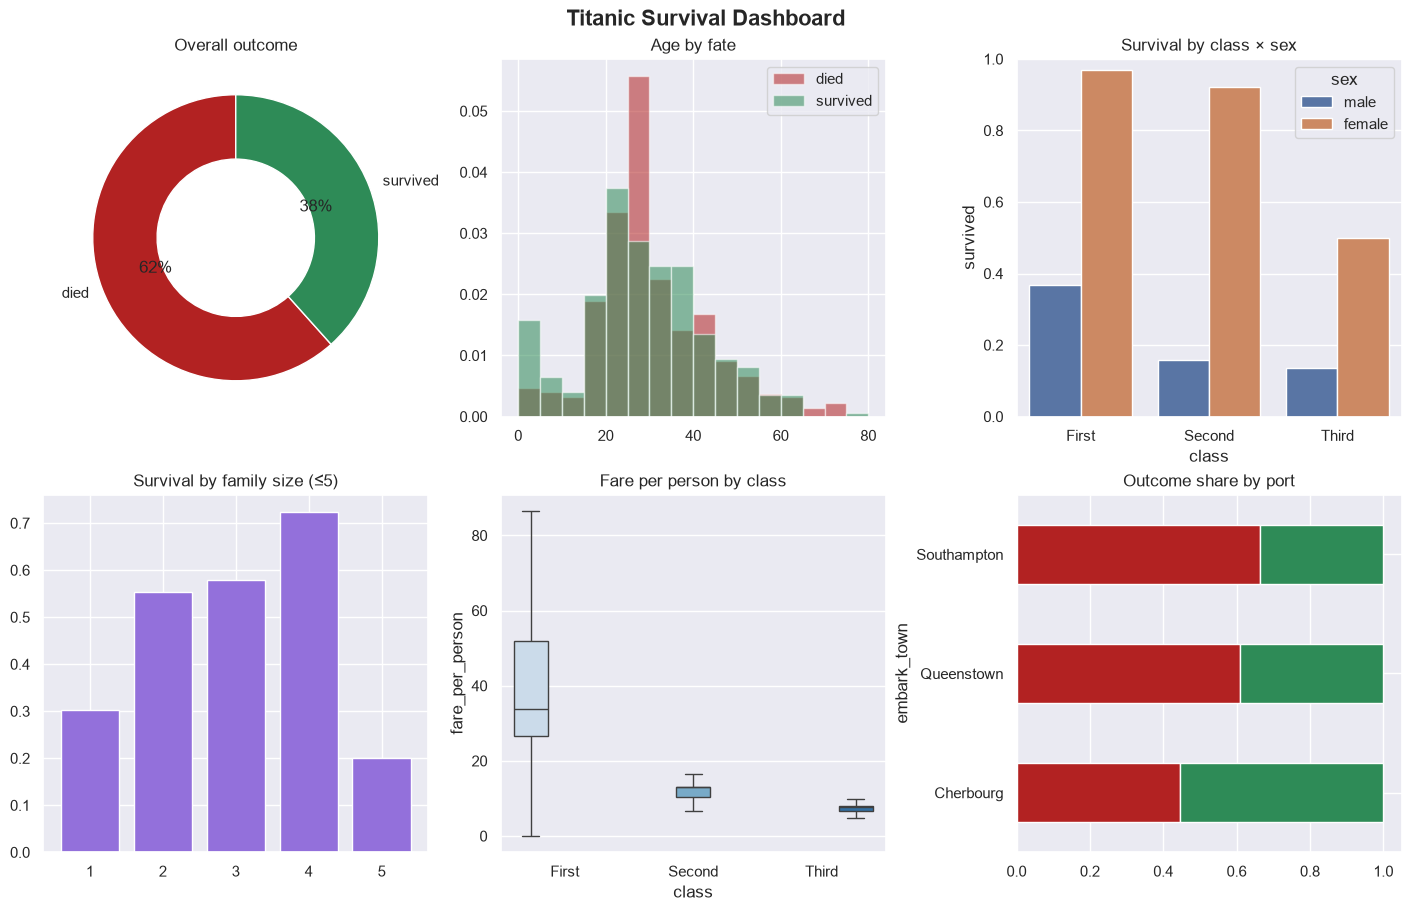

In [10]:
fig = plt.figure(figsize=(14, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

# 1) overall donut
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(df["survived"].value_counts().sort_index(),
        labels=["died", "survived"], colors=["firebrick", "seagreen"],
        autopct="%1.0f%%", startangle=90,
        wedgeprops=dict(width=.45, edgecolor="white"))
ax1.set_title("Overall outcome")

# 2) age distribution by fate
ax2 = fig.add_subplot(gs[0, 1])
for val, color in [(0, "firebrick"), (1, "seagreen")]:
    ax2.hist(df.loc[df.survived == val, "age"], bins=np.arange(0, 85, 5),
             alpha=.55, color=color, density=True, label="survived" if val else "died")
ax2.set_title("Age by fate"); ax2.legend()

# 3) survival by class & sex (the money chart, compact)
ax3 = fig.add_subplot(gs[0, 2])
sns.barplot(data=df, x="class", y="survived", hue="sex",
            errorbar=None, ax=ax3)
ax3.set_title("Survival by class × sex"); ax3.set_ylim(0, 1)

# 4) family size effect
ax4 = fig.add_subplot(gs[1, 0])
fam = df[df.family_size <= 5].groupby("family_size", observed=True)["survived"].mean()
ax4.bar(fam.index.astype(str), fam.values, color="mediumpurple")
ax4.set_title("Survival by family size (≤5)")

# 5) fare per person box by class
ax5 = fig.add_subplot(gs[1, 1])
sns.boxplot(data=df, x="class", y="fare_per_person", showfliers=False, ax=ax5,
            palette="Blues", hue="class", legend=False)
ax5.set_title("Fare per person by class")

# 6) embarkation mix
ax6 = fig.add_subplot(gs[1, 2])
port = pd.crosstab(df["embark_town"], df["survived"], normalize="index")
port.plot(kind="barh", stacked=True, ax=ax6,
          color=["firebrick", "seagreen"], legend=False)
ax6.set_title("Outcome share by port")

fig.suptitle("Titanic Survival Dashboard", fontsize=16, fontweight="bold")
plt.show()

### Findings

1. Overall survival was **38.4%**; outcomes ranged from ~15% (3rd-class men)
   to ~97% (1st-class women).
2. **Sex was the dominant factor**: women survived ~74% vs men ~19% overall.
3. **Class gradient within each sex**: 1st 63% → 2nd 47% → 3rd 24%.
4. Children (≤12) showed elevated survival in 2nd/3rd class - consistent with
   evacuation policy, though samples are small.
5. **Solo travelers fared worse** than small families (peak benefit at size 2-4);
   very large families (>5) collapsed toward low rates.
6. Fare per person separates classes cleanly even after normalizing group
   tickets - a better engineered feature than raw fare.
7. Port effects (Cherbourg higher) largely REFLECT class composition, not the
   port itself - a confounding lesson.

### Limitations
- Age imputation (group medians) adds uncertainty to age-based splits.
- Crew excluded from this dataset; historical crew survival was far lower.
- Correlation ≠ causation: no causal claim survives this design.

### Recommendations to the stakeholder
Use these segments for the risk-communication case study; if modeling next,
start with sex, pclass, age, family_size, fare_per_person.

### Summary & key takeaways

- Auditing FIRST (nullity map, duplicate check) dictates the cleaning plan.
- Structural missingness (deck) → drop; informative missingness deserves a note.
- Engineered features (family_size, fare/person, age bands) unlock clearer stories.
- Always pair rates with sample sizes; interactions (sex×class) beat single cuts.
- A dashboard = many angles on one question, sharing one visual language.